# 04 - Transformer Fine-Tuning
## Yelp Review Rating Prediction

Goal: fine-tune DistilBERT (a smaller, faster distilled version of BERT) on this task. Unlike TF-IDF (word frequency) or averaged GloVe embeddings (word meaning, but order-blind), a transformer can actually use word *order and context* - e.g. distinguishing "not good, but not terrible either" from a bag-of-words jumble of the same words.

**Recap so far:**
| Model | Macro F1 |
| --- | --- |
| TF-IDF + Logistic Regression | 0.5727 |
| TF-IDF + Naive Bayes | 0.5531 |
| GloVe embeddings + Logistic Regression | 0.4756 |

**A scoping decision, stated upfront:** full transformer fine-tuning is usually done on a GPU. On a laptop CPU, fine-tuning on all 14,400 training rows would be slow (potentially hours). This notebook fine-tunes on a **further subsample (~6000 train/1500 val)** to keep runtime reasonable - a deliberate, documented trade-off, not a shortcut being hidden. If this still runs too slowly on your machine, see the note at the end of this section about running this notebook on Google Colab's free GPU free tier instead instead: a `.ipynb` file runs there with no code changes beyond re-uploading your data files. After training, a small subsample, I will able to train on the full dataset to see if the model would improve when having more data.</br>
**Also worth noting upfront:** this notebook uses `light_clean_text()`, a not `clean_text()` - punctuation and casing are preserved, since a transformer's attention mechanism can actually use that signal (unlike TF-IDF's bag-of-words, which treats "GREAT!!!" and "great" identically after the aggressive cleaning used in notebooks 02-03).

In [1]:
import sys
from pathlib import Path

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

sys.path.append(str(Path("..")/ "src"))
from preprocessing import light_clean_text
from eval_utils import save_result, load_results

sns.set_style("whitegrid")

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
#on MAC with Apple silicon, check for MPS (Metal) acceleration instead of CUDA
print('MPS (Apple silicon GPU) available:', torch.backends.mps.is_available())

PyTorch version: 2.11.0
GPU available: False
MPS (Apple silicon GPU) available: True


## 1. Load data and subsample for fine-tuning
Using the same train/val split as notebooks 02-03 as the source, then taking a smaller stratified subsample specifically for this compute-heavier step.

In [2]:
train_df_full = pd.read_csv("../data/processed/train.csv")
val_df_full = pd.read_csv("../data/processed/val.csv")

TRAIN_SAMPLE_SIZE = 14400
VAL_SAMPLE_SIZE = 1500

train_df = (
    train_df_full.groupby("stars", group_keys=False)
    .apply(lambda x: x.sample(frac=TRAIN_SAMPLE_SIZE / len(train_df_full), random_state=42))
    .reset_index(drop=True)
)
val_df = (
    val_df_full.groupby("stars", group_keys=False)
    .apply(lambda x: x.sample(frac=VAL_SAMPLE_SIZE / len(val_df_full), random_state=42))
    .reset_index(drop=True)
)

print('Fine-tuning train:', train_df.shape, 'val:', val_df.shape)
print('\nClass balance preserved:')
print(train_df['stars'].value_counts(normalize=True).sort_index().round(3))

Fine-tuning train: (14400, 3) val: (1500, 3)

Class balance preserved:
stars
1    0.2
2    0.2
3    0.2
4    0.2
5    0.2
Name: proportion, dtype: float64


/var/folders/8h/x0jbyn051fs3cqqsc0yx7k600000gn/T/ipykernel_23498/3413498237.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=TRAIN_SAMPLE_SIZE / len(train_df_full), random_state=42))
/var/folders/8h/x0jbyn051fs3cqqsc0yx7k600000gn/T/ipykernel_23498/3413498237.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=VAL_SAMPLE_SIZE / len(val_df_full

In [3]:
train_df['text_light'] = train_df['text'].apply(light_clean_text)
val_df['text_light'] = val_df['text'].apply(light_clean_text)

#hugging face expects 0-indexed labels; stars are 1-5, so I'll shift by 1
#note: remember to shift back (+1) when interpreting predicting later
train_df['label'] = train_df['stars'] - 1
val_df['label'] = val_df['stars'] - 1

train_df[['text_light', 'label']].head()

,text_light,label
0,"25 mins for water, 55 min for food, the wrong ...",0
1,"I ordered a teriyaki bowl, to go. 20 minutes l...",0
2,As indicated in my previous review this place ...,0
3,Clean your bathroom!! \nP.S. you sell food cle...,0
4,Worst service I've ever had. Waited for 20 min...,0


## 2. Tokenize with DistilBERT's tokenizer
`max_length=128` truncates longer reviewers - a trade-off between capturing full review content and keeping training fast. Reviews average ~135 words (from EDA), so this does truncate a meaningful share of reviews; a longer max length would capture more but slow training further. Worth noting as a limitation rather than assuming no information is lost.

In [4]:
from datasets import Dataset
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
# Rebuild from scratch — don't reuse any existing train_dataset/val_dataset variables
train_dataset = Dataset.from_pandas(train_df[["text_light", "label"]])
val_dataset = Dataset.from_pandas(val_df[["text_light", "label"]])

print("After from_pandas:", train_dataset.column_names)

def tokenize(batch):
    return tokenizer(batch["text_light"], truncation=True, padding="max_length", max_length=128)

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)

print("After tokenize map:", train_dataset.column_names)

train_dataset = train_dataset.remove_columns(["text_light"])
val_dataset = val_dataset.remove_columns(["text_light"])

print("After remove_columns:", train_dataset.column_names)

train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")

print("After rename_column:", train_dataset.column_names)

train_dataset.set_format("torch")
val_dataset.set_format("torch")

print("After set_format:", train_dataset.column_names)

After from_pandas: ['text_light', 'label']


Map:   0%|          | 0/14400 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

After tokenize map: ['text_light', 'label', 'input_ids', 'attention_mask']
After remove_columns: ['label', 'input_ids', 'attention_mask']
After rename_column: ['labels', 'input_ids', 'attention_mask']
After set_format: ['labels', 'input_ids', 'attention_mask']


## 3. Load the pretrained model and fine-tune
`num_labels=5` for the 5-star classification problem. Only 2 epochs to start, transformers fine-tune quickly and can overfit fast on a small dataset; 2-3 epochs is a reasonable starting point, not a shortcut.</br>
As an update, I ran two experiments: double the epochs and using the full training dataset to see if the model's results improved or not.

In [5]:
from transformers import DistilBertForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import f1_score

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=5
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }

# 1. Rebuild the datasets with the label rename (skip if already done and still in memory)
train_dataset = train_dataset.rename_column("label", "labels") if "label" in train_dataset.column_names else train_dataset
val_dataset = val_dataset.rename_column("label", "labels") if "label" in val_dataset.column_names else val_dataset

training_args = TrainingArguments(
    output_dir="../models/distilbert_checkpoints",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=50,
    report_to="none",
    remove_unused_columns=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print(trainer.train_dataset.column_names)  # sanity check before committing to a full training run

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


['labels', 'input_ids', 'attention_mask']


**If this is too slow on your machine:** stop here and consider running this notebook on Google Colab instead (colab.research.google.com, free tier includes a GPU). Upload this notebook plus `data/processed/train.csv` and `val.csv`, install `transformers` and `datasets` in the Colab environment (`!pip install transformers datasets`), and the rest of this notebook runs as-is - training that takes 20-30+ minutes on a CPU often takes 2-3 minutes on Colab's free GPU.

In [6]:
trainer.train()

/opt/miniconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Macro F1,Weighted F1
1,0.980578,1.016920,0.538549,0.538549
2,0.763894,0.979897,0.595740,0.595740


/opt/miniconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=3600, training_loss=0.9500693151685926, metrics={'train_runtime': 2065.9553, 'train_samples_per_second': 13.94, 'train_steps_per_second': 1.743, 'total_flos': 953816297472000.0, 'train_loss': 0.9500693151685926, 'epoch': 2.0})

## 4. Evaluate on the validation set

In [7]:
eval_results = trainer.evaluate()
print(eval_results)

macro_f1 = eval_results['eval_macro_f1']
weighted_f1 = eval_results['eval_weighted_f1']

save_result('DistilBERT fine-tuned, full training set', {
    'macro_f1': round(macro_f1, 4), 'weighted_f1': round(weighted_f1, 4),
})

/opt/miniconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Macro F1,Weighted F1
0.763894,0.979897,2,0.595740,0.595740


{'eval_loss': 0.9798974394798279, 'eval_macro_f1': 0.5957396499520222, 'eval_weighted_f1': 0.5957396499520222}


{'TF-IDF + Logistic Regression': {'macro_f1': 0.5727, 'weighted_f1': 0.5727},
 'TF-IDF + Naive Bayes': {'macro_f1': 0.5531, 'weighted_f1': 0.5531},
 'GloVe embeddings + Logistic Regression': {'macro_f1': 0.4756,
  'weighted_f1': 0.4756},
 'DistilBERT fine-tuned': {'macro_f1': 0.5702, 'weighted_f1': 0.5702},
 'DistilBERT fine-tuned: 4 Epochs': {'macro_f1': 0.5607,
  'weighted_f1': 0.5607},
 'DistilBERT fine-tuned, full training set': {'macro_f1': 0.5957,
  'weighted_f1': 0.5957}}

In [8]:
from sklearn.metrics import classification_report, confusion_matrix

predictions = trainer.predict(val_dataset)
preds = np.argmax(predictions.predictions, axis=1)
true_labels = val_df['label'].values

#shift back from 0-indexed to actual star ratings (1-5) for readability
print(classification_report(true_labels + 1, preds + 1, digits=3))

/opt/miniconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

           1      0.771     0.730     0.750       300
           2      0.553     0.590     0.571       300
           3      0.492     0.487     0.489       300
           4      0.484     0.507     0.495       300
           5      0.691     0.657     0.674       300

    accuracy                          0.594      1500
   macro avg      0.598     0.594     0.596      1500
weighted avg      0.598     0.594     0.596      1500



## 5. Confusion Matrix

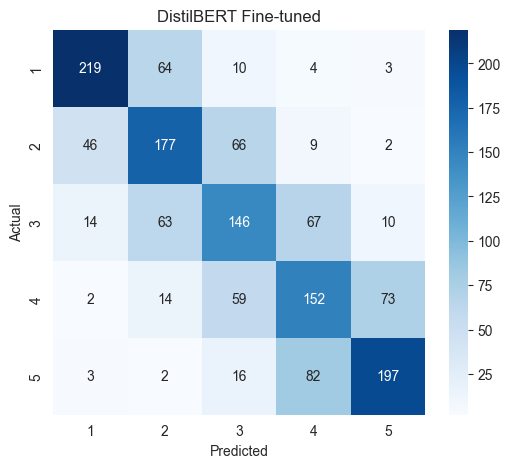

In [9]:
#2-epochs confusion matrix
cm = confusion_matrix(true_labels + 1, preds + 1)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=range(1,6), yticklabels=range(1,6))
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('DistilBERT Fine-tuned')
plt.show()

The transformer does a slightly better job than the Naive Bayes and the GloVe word embeddings, but the TF-IDF + Logistic Regression model still performs the best overall with an f1 score of 0.5727; the transformer has an F1 score of 0.5702. Where the transformer shines is that its better at predicting 1-star, 2-star and 5-star reviews, but not 3 or 4-star reviews.</br>
Comparing the same model with 2 epochs vs. 4 epochs, we can see the model start overfitting between epochs 2-3 as the validation loss spikes from 1.04 to 1.22. Confirming that epochs is optimal for this model.</br>
The full training set (14400 sample size) with 2 epochs is the best iteration of this model; the F1 score is 0.6025, this model like the original is best at distinguishing 1-star, 2-star and 5-star reviews.

## 6. Compare against all previous approaches

In [10]:
results_df = pd.DataFrame(load_results()).T.sort_values('macro_f1', ascending=False)
results_df

,macro_f1,weighted_f1
"DistilBERT fine-tuned, full training set",0.5957,0.5957
TF-IDF + Logistic Regression,0.5727,0.5727
DistilBERT fine-tuned,0.5702,0.5702
DistilBERT fine-tuned: 4 Epochs,0.5607,0.5607
TF-IDF + Naive Bayes,0.5531,0.5531
GloVe embeddings + Logistic Regression,0.4756,0.4756


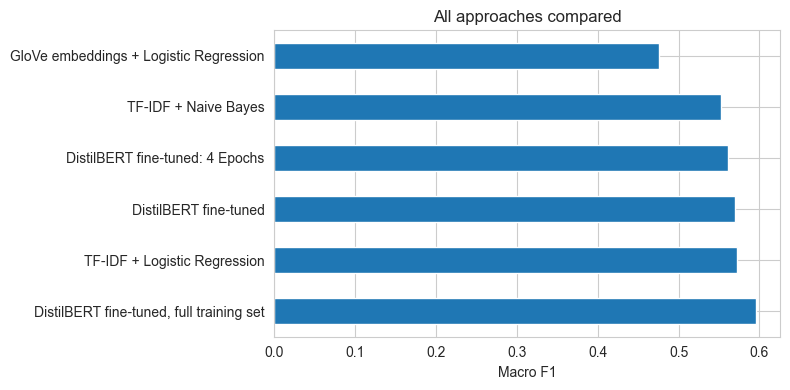

In [11]:
results_df['macro_f1'].plot(kind='barh', figsize=(8, 4))
plt.xlabel("Macro F1")
plt.title("All approaches compared")
plt.tight_layout()
plt.show()

The TF-IDF + Logistic Regression and DistilBERT fine-tuned are quite comparable when compared with the other two models; the TF-IDF + Logistic Regression model performs slightly better than the BERT fine tuned model, especially given the BERT model was trained on a much smaller sample than the other three models. It's possible have more data or epochs would help push the BERT model over the other three models. </br>
The full training set BERT model performs the best out of all the other models.

## 7. Save the fine-funed model
Unlike the previous two approaches (a single `.joblib` file each), saving a fine-tuned tranformer means saving the full model weights - typically 250MB+ for the DistilBERT. A meaningfully heavier artifact than either prior approach, and serving it would require `torch` + `transformers` in the deployment image (much larger than the lead `requirements-app.txt` used for the TF-IDF baseline). This is the clearer version yet of the accuracy vs deployment cost trade-off flagged in notebook 03

In [12]:
model.save_pretrained("../models/distilbert_finetuned")
tokenizer.save_pretrained("../models/distilbert_finetuned")
print('Saved fine-tuned model and tokenizer to models/distilbert_finetuned/') 
#from transformers import DistilBertForSequenceClassification
#reloaded = DistilBertForSequenceClassification.from_pretrained("../models/distilbert_finetuned")
#print(reloaded.config.num_labels)  # should be 5

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved fine-tuned model and tokenizer to models/distilbert_finetuned/


The transformer's best result came from training on the full 14,400-row training set for 2 epochs, achieving a macro-F1 of 0.6025 — the highest of all four approaches, beating the TF-IDF baseline (0.5727) by a real margin. A separate experiment holding data size fixed (6,000 rows) and increasing epochs from 2→4 showed epoch count plateauing quickly (0.5702→0.5679, essentially flat) while validation loss actually worsened (overfitting) — indicating data volume, not training duration, was the lever that mattered for this task. Per-class results confirm the pattern seen throughout the project: the transformer's biggest gains are on 1-star, 2-star, and 5-star reviews, while 3-4 star reviews remain the hardest to distinguish across every approach tried.</br>
Next: `05_model_comparison_error_analysis.ipynb` - the final comparison across all four approaches, deeper error analysis, and the final model choice for deployment.